# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

### From the plot, I observed....
Results: There is a positive correlation between `Attack` and `Defense`. The hit-points (`HP`) is higher for Pokemons with higher `Attack` and `Defense` values.

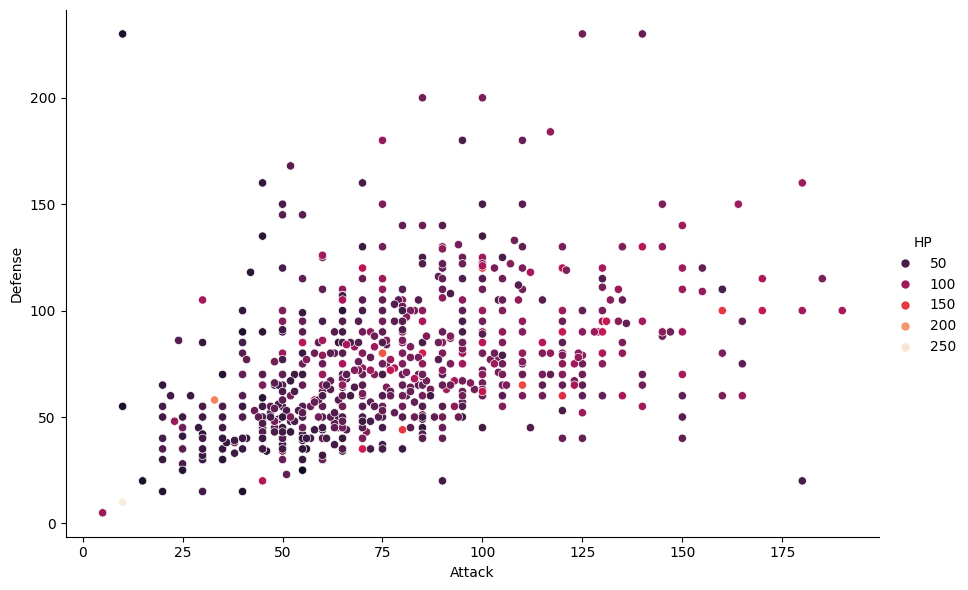

In [2]:
data = pd.read_csv(fp)

attack_defense = sns.relplot(
    data=data,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="rocket",
    height=6,
    aspect=1.5,
    kind="scatter"
)

From the plot i observed that there is a positive correlation between `Attack` and `Defense`. `HP` is higher for Pokemons with higher `Attack` and `Defense` values.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

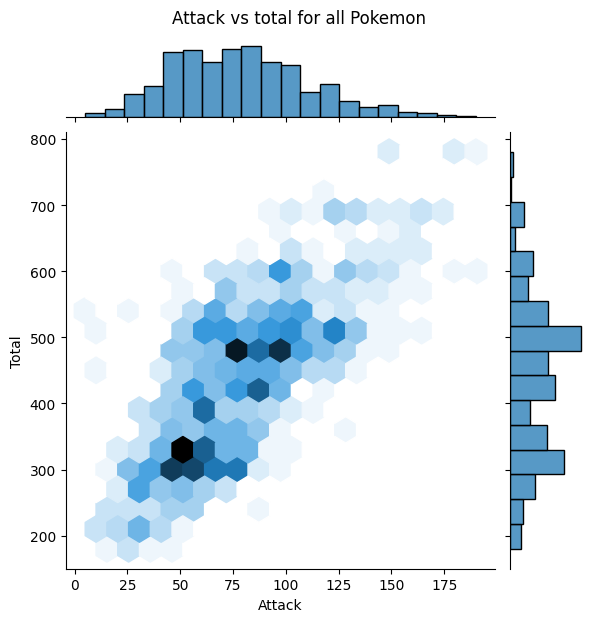

In [6]:
attack_total = sns.jointplot(

    data=data,
    x="Attack",
    y="Total",
    kind="hex",
    height=6
)

attack_total.fig.suptitle("Attack vs total for all Pokemon", y=1.03);

From the plot i observed that there is a positive correlation between `Attack` and `Total` much like attack and defense. `Attack` grows higher along with `Total` values

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

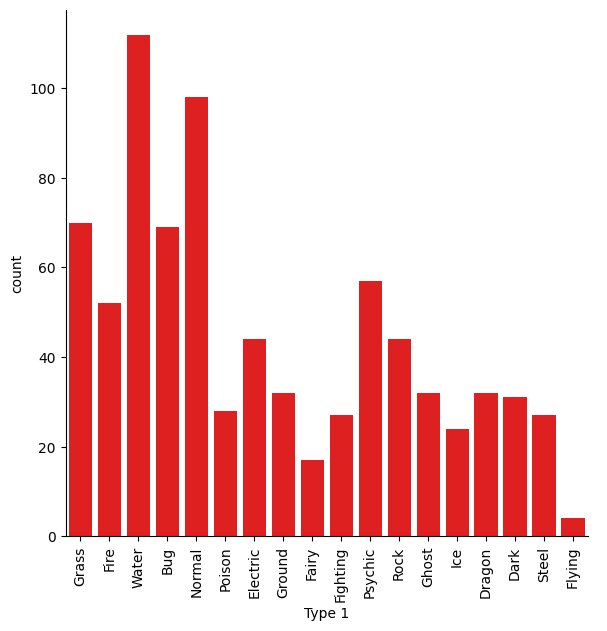

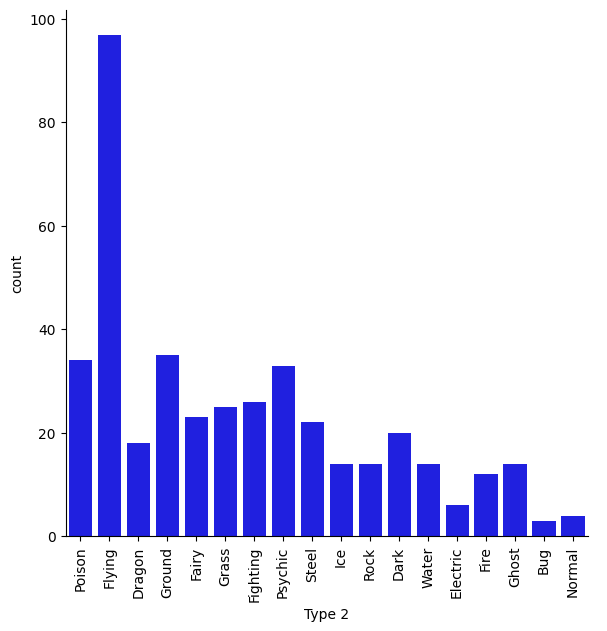

In [10]:
type1 = sns.catplot(
    data=data,
    x="Type 1",
    kind="count",
    height=6,
    aspect=1,
    color="red"
)
type1.set_xticklabels(rotation=90)

type2 = sns.catplot(
    data=data,
    x="Type 2",
    kind="count",
    height=6,
    aspect=1,
    color="blue"
)
type2.set_xticklabels(rotation=90)

The most common `Type 1` Pokemon is Water, Normal and Grass.

The most rare `Type 1` Pokemon are Flying and Fairy.

The most common `Type 2` Pokemon is Flying, Ground and Poison.

The most rare `Type 2` Pokemon include bug and normal.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

## comparison between multi-type and mono-type pokemon total stats

In [26]:
import numpy as np

In [12]:
data['Type_Category'] = np.where(data['Type 2'].isnull(), 'Mono-type', 'Multi-type')
print(" 'Type_Category' column created successfully.")
data.head()

 'Type_Category' column created successfully.


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Type_Category
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False,Multi-type
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False,Multi-type
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False,Multi-type
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False,Multi-type
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False,Mono-type


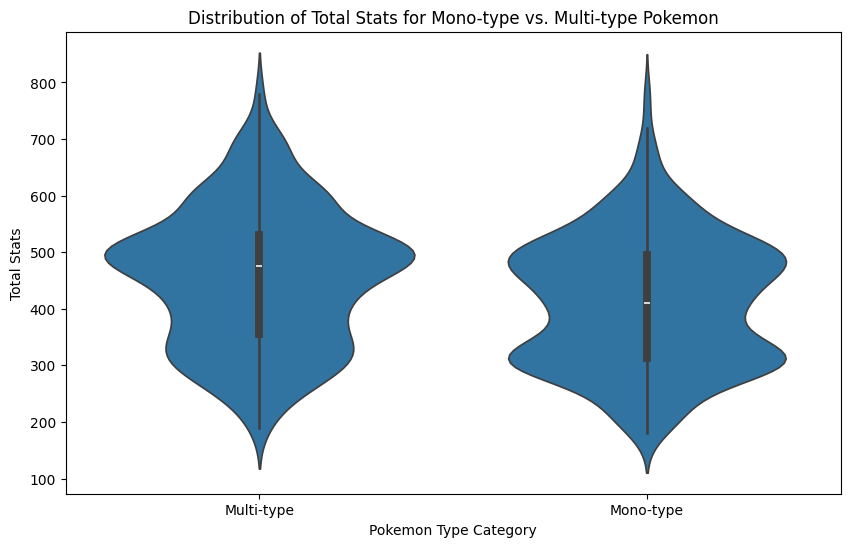

In [13]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='Type_Category', y='Total', data=data)
plt.title('Distribution of Total Stats for Mono-type vs. Multi-type Pokemon')
plt.xlabel('Pokemon Type Category')
plt.ylabel('Total Stats')
plt.show()

### Observation on plot
The violin plot indicates that Multi-type Pokemon generally have higher total stats than Mono-type Pokemon. The distribution for Multi-type Pokemon is also wider, suggesting a greater range of total stats, including some with very high values, compared to Mono-type Pokemon.

## highest stat for each type

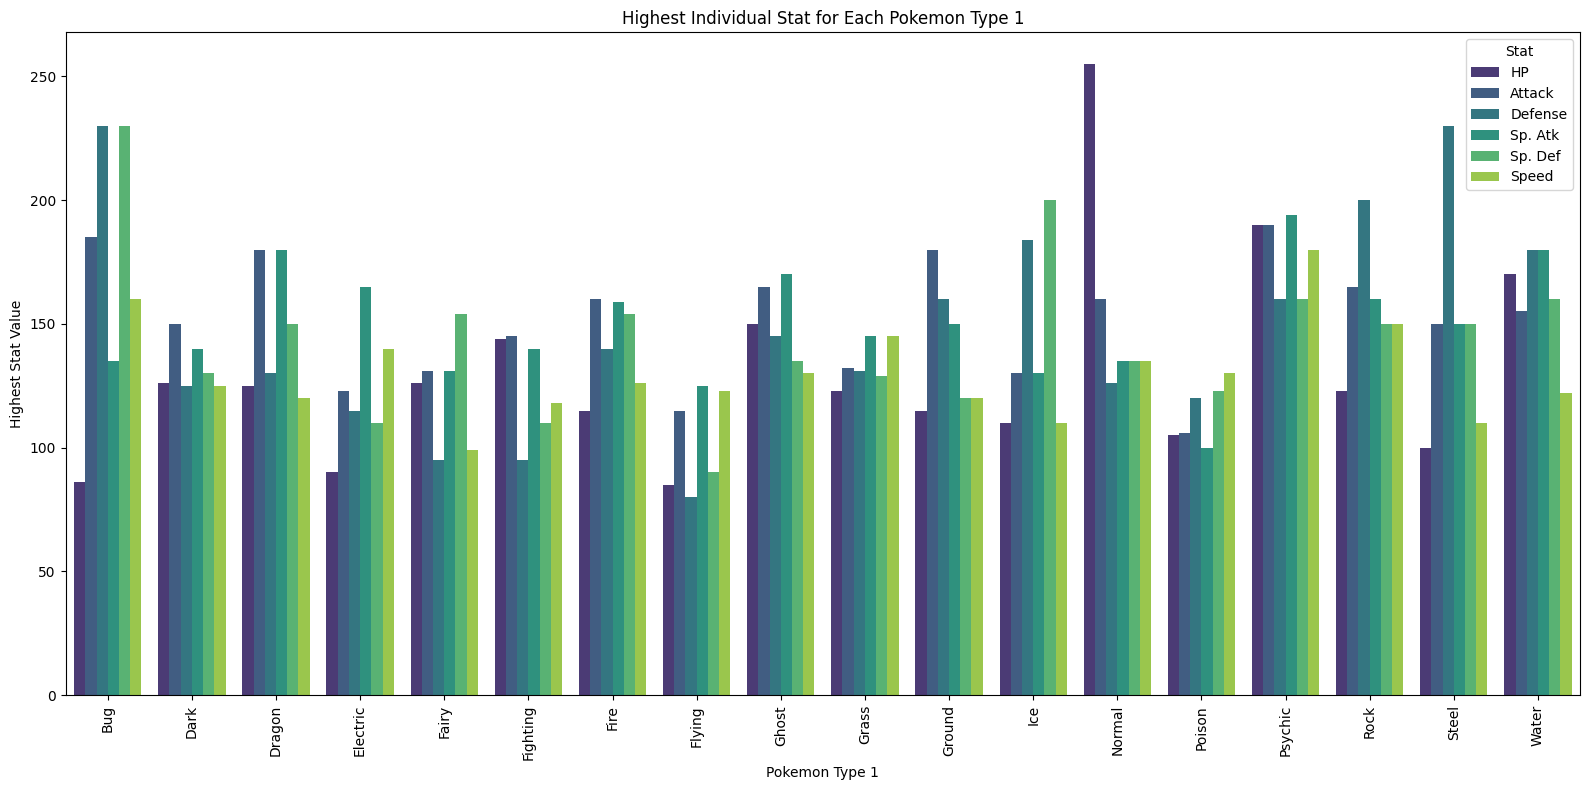

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


stat_columns = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']


max_stats_by_type = data.groupby('Type 1')[stat_columns].max().reset_index()


melted_stats = max_stats_by_type.melt(id_vars='Type 1', var_name='Stat', value_name='Max_Value')


plt.figure(figsize=(16, 8))
sns.barplot(data=melted_stats, x='Type 1', y='Max_Value', hue='Stat', palette='viridis')
plt.xticks(rotation=90)
plt.title('Highest Individual Stat for Each Pokemon Type 1')
plt.xlabel('Pokemon Type 1')
plt.ylabel('Highest Stat Value')
plt.legend(title='Stat')
plt.tight_layout()
plt.show()

### Observations from the 'Highest Individual Stat for Each Pokemon Type 1' Plot:

Attack, defense, and special attack are usually higher across all types and HP is the highest in water and normal types.

**Balanced vs. Specialized Types:** Some types, like Dragon and Psychic, appear to have high maximums across multiple offensive and defensive stats, indicating overall powerful Pokémon. Other types might specialize more, excelling primarily in one or two stats.

## Filter Legendary Pokemon by type



In [21]:
legendary_pokemon_df = data[data['Legendary'] == True]
print("Legendary Pokemon DataFrame created successfully.")
legendary_pokemon_df.head()

Legendary Pokemon DataFrame created successfully.


,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary,Type_Category
156,144,Articuno,Ice,Flying,580,90,85,100,95,125,85,1,True,Multi-type
157,145,Zapdos,Electric,Flying,580,90,90,85,125,90,100,1,True,Multi-type
158,146,Moltres,Fire,Flying,580,90,100,90,125,85,90,1,True,Multi-type
162,150,Mewtwo,Psychic,NaN,680,106,110,90,154,90,130,1,True,Mono-type
163,150,MewtwoMega Mewtwo X,Psychic,Fighting,780,106,190,100,154,100,130,1,True,Multi-type


In [22]:
type1_counts = legendary_pokemon_df['Type 1'].value_counts()
type2_counts = legendary_pokemon_df['Type 2'].value_counts()
print("Counts for Type 1 and Type 2 of legendary Pokemon calculated.")
print("Type 1 Counts:\n", type1_counts)
print("Type 2 Counts:\n", type2_counts)

Counts for Type 1 and Type 2 of legendary Pokemon calculated.
Type 1 Counts:
 Type 1
Psychic     14
Dragon      12
Fire         5
Rock         4
Water        4
Steel        4
Electric     4
Ground       4
Grass        3
Ice          2
Normal       2
Ghost        2
Dark         2
Flying       2
Fairy        1
Name: count, dtype: int64
Type 2 Counts:
 Type 2
Flying      13
Psychic      5
Fighting     4
Dragon       4
Fire         3
Ice          3
Fairy        2
Electric     1
Steel        1
Ground       1
Ghost        1
Dark         1
Water        1
Name: count, dtype: int64


In [23]:
combined_legendary_type_counts = type1_counts.add(type2_counts, fill_value=0).sort_values(ascending=False)
print("Combined legendary type counts calculated successfully.")
print("Combined Legendary Type Counts:\n", combined_legendary_type_counts.head())

Combined legendary type counts calculated successfully.
Combined Legendary Type Counts:
 Psychic    19.0
Dragon     16.0
Flying     15.0
Fire        8.0
Ice         5.0
Name: count, dtype: float64


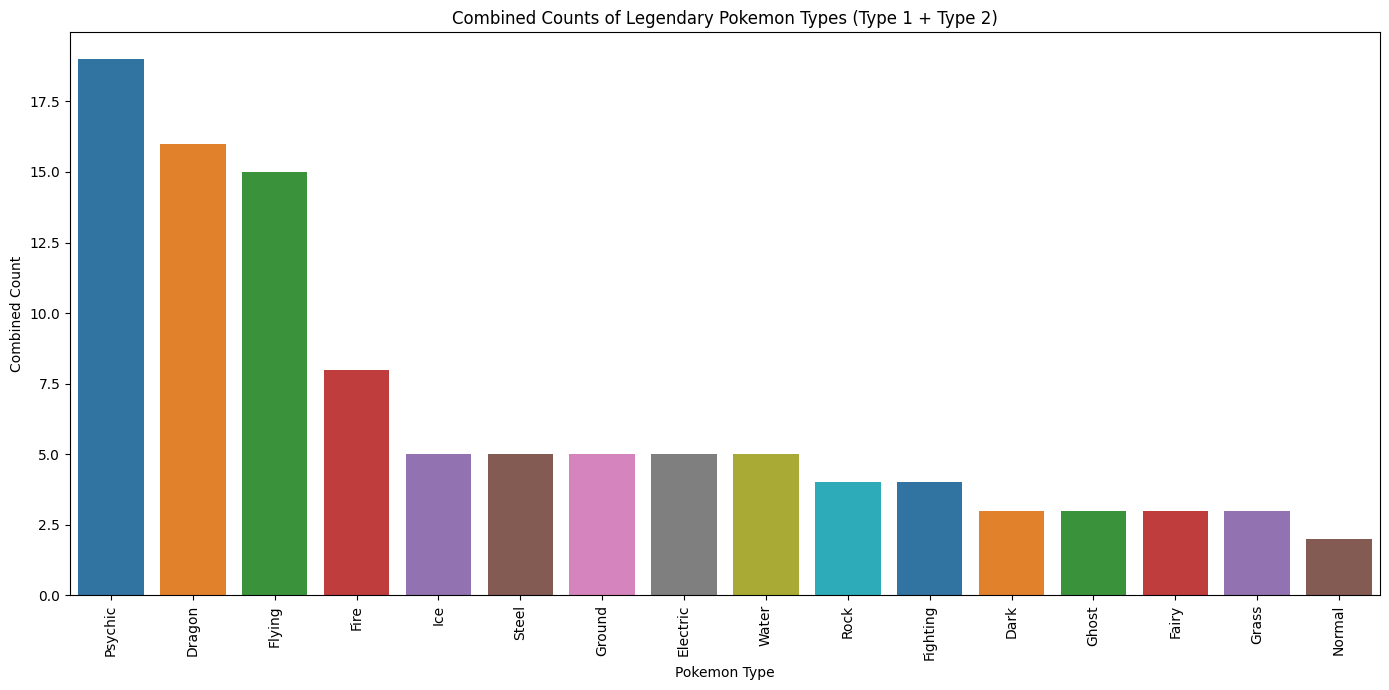

In [27]:
plt.figure(figsize=(14, 7))
sns.barplot(x=combined_legendary_type_counts.index, y=combined_legendary_type_counts.values, hue=combined_legendary_type_counts.index, palette='tab10', legend=False)
plt.xticks(rotation=90)
plt.title('Combined Counts of Legendary Pokemon Types (Type 1 + Type 2)')
plt.xlabel('Pokemon Type')
plt.ylabel('Combined Count')
plt.tight_layout()
plt.show()

### Observations from the Legendary Pokemon Type Counts Plot:

From the bar plot showing the combined counts of 'Type 1' and 'Type 2' for legendary Pokemon, we can observe the following:

This distribution suggests that certain types, particularly Psychic, Dragon, and Flying, are heavily favored in the design of legendary Pokemon.